In [1]:
# === Setup ===
import os, random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## 1) Daten laden

In [2]:
# Daten-Datei (CSV) – hier entweder im Notebook-Ordner oder im /mnt/data Ordner.
CSV_PATH = "free_throw_dataset.csv"
if not os.path.exists(CSV_PATH):
    alt = os.path.join("/mnt/data", CSV_PATH)
    if os.path.exists(alt):
        CSV_PATH = alt

df = pd.read_csv(CSV_PATH)
print("CSV_PATH:", CSV_PATH)
print(df.shape)
print(df.columns.tolist())
df.head()

CSV_PATH: free_throw_dataset.csv
(7500, 12)
['wurf_id', 't', 'x_clean', 'y_clean', 'x_noisy', 'y_noisy', 'x', 'y', 'T', 'label', 'theta', 'v0']


,wurf_id,t,x_clean,y_clean,x_noisy,y_noisy,x,y,T,label,theta,v0
0,0,0.000000,0.000000,2.662500,0.157921,2.578578,0.157921,2.578578,0.696893,0,0.70767,6.107672
1,0,0.014222,0.066007,2.717976,0.142750,2.687055,0.142750,2.687055,0.696893,0,0.70767,6.107672
2,0,0.028445,0.132014,2.771469,0.085067,2.804595,0.085067,2.804595,0.696893,0,0.70767,6.107672
3,0,0.042667,0.198021,2.822978,0.252277,2.920532,0.252277,2.920532,0.696893,0,0.70767,6.107672
4,0,0.056889,0.264028,2.872503,0.217686,2.824585,0.217686,2.824585,0.696893,0,0.70767,6.107672


In [3]:
# Pro Wurf aggregieren
per_throw = df.groupby("wurf_id").agg({
    "label":"first",
    "theta":"first",
    "v0":"first",
    "T":"first"
}).reset_index()

print("Anzahl Würfe:", per_throw.shape[0])
print(per_throw["label"].value_counts())
per_throw.head()

Anzahl Würfe: 150
label
0    50
1    50
2    50
Name: count, dtype: int64


,wurf_id,label,theta,v0,T
0,0,0,0.707670,6.107672,0.696893
1,1,1,0.889089,6.662367,0.974337
2,2,2,0.759879,6.803414,0.864825
3,3,0,0.762547,6.383944,0.801193
4,4,1,0.793452,6.633317,0.874307


## 2) Train/Val/Test Split (nach `wurf_id`, stratifiziert nach Label)

In [4]:
# labels_by_id = df.groupby("wurf_id")["label"].first().to_dict()

# all_ids = np.array(sorted(labels_by_id.keys()))
# all_y = np.array([labels_by_id[i] for i in all_ids])

# train_ids, temp_ids, y_train, y_temp = train_test_split(
#     all_ids, all_y, test_size=0.3, stratify=all_y, random_state=42  # z.B. 70/30
# )

# val_ids, test_ids, y_val, y_test = train_test_split(
#     temp_ids,
#     y_temp,
#     test_size=0.5,  # 0.5 von 30% = 15%/15%
#     stratify=y_temp,
#     random_state=42,
# )

# train_ids = train_ids.tolist()
# val_ids = val_ids.tolist()
# test_ids = test_ids.tolist()

# print("Train IDs:", len(train_ids))
# print("Val IDs:", len(val_ids))
# print("Test IDs:", len(test_ids))
train_ids, test_ids = train_test_split(
    per_throw["wurf_id"].values,
    test_size=0.15,
    random_state=SEED,
    stratify=per_throw["label"].values,
)
train_ids, val_ids = train_test_split(
    train_ids,
    test_size=0.15,
    random_state=SEED,
    stratify=per_throw.set_index("wurf_id").loc[train_ids, "label"].values,
)

print("Train/Val/Test:", len(train_ids), len(val_ids), len(test_ids))
print("Alle Test ids:", test_ids)

Train/Val/Test: 107 20 23
Alle Test ids: [131 119  84 124  24  22   9  11  89  57 148  31  69  85  71 141   1  41
 117 106  42 143  70]


## 3) Dataset: gekürzte Beobachtungen + Ground Truth

In [5]:
class FreeThrowDataset(Dataset):
    """
    Liefert pro Wurf die ersten n_obs Beobachtungen (t_obs, xy_obs) und die komplette Trajektorie (t_full, xy_full).

    Wichtig: kein Zukunftswissen via T/t_max – stattdessen liefern wir t_min, t_obs_max und denom = t_obs_max - t_min
    fuer eine zeitliche Normalisierung relativ zum Beobachtungsfenster.
    """
    def __init__(self, df: pd.DataFrame, throw_ids, n_obs: int = 30, use_noisy: bool = False):
        self.n_obs = n_obs
        self.use_noisy = use_noisy

        sub = df[df["wurf_id"].isin(throw_ids)].copy()
        sub.sort_values(["wurf_id", "t"], inplace=True)

        self.throw_ids = np.array(sorted(sub["wurf_id"].unique()))
        self.groups = {tid: g for tid, g in sub.groupby("wurf_id")}

        if use_noisy:
            self.x_col, self.y_col = "x_noisy", "y_noisy"
        else:
            self.x_col, self.y_col = "x_clean", "y_clean"

    def __len__(self):
        return len(self.throw_ids)

    def __getitem__(self, idx):
        tid = int(self.throw_ids[idx])
        g = self.groups[tid]

        t = torch.tensor(g["t"].values, dtype=torch.float32)  # (M,)
        xy = torch.tensor(
            np.stack([g[self.x_col].values, g[self.y_col].values], axis=1),
            dtype=torch.float32
        )  # (M,2)

        t_obs = t[:self.n_obs]
        xy_obs = xy[:self.n_obs]

        theta = torch.tensor(float(g["theta"].iloc[0]), dtype=torch.float32)
        v0 = torch.tensor(float(g["v0"].iloc[0]), dtype=torch.float32)
        label = torch.tensor(int(g["label"].iloc[0]), dtype=torch.long)

        # Zeit-Normalisierung nur ueber beobachtetes Fenster:
        t_min = t_obs[0]
        t_obs_max = t_obs[-1]
        denom = (t_obs_max - t_min).clamp_min(1e-4)

        return {
            "wurf_id": tid,
            "t_obs": t_obs,          # (n_obs,)
            "xy_obs": xy_obs,        # (n_obs,2)
            "t_full": t,             # (M,)
            "xy_full": xy,           # (M,2)
            "t_min": t_min,          # ()
            "t_obs_max": t_obs_max,  # ()
            "denom": denom,          # ()
            "theta": theta,
            "v0": v0,
            "label": label,
        }

def collate_fn(batch):
    out = {}
    for k in batch[0].keys():
        if k == "wurf_id":
            out[k] = [b[k] for b in batch]
        else:
            out[k] = torch.stack([b[k] for b in batch], dim=0)
    return out

n_obs = 30
train_ds = FreeThrowDataset(df, train_ids, n_obs=n_obs, use_noisy=False)
val_ds   = FreeThrowDataset(df, val_ids,   n_obs=n_obs, use_noisy=False)
test_ds  = FreeThrowDataset(df, test_ids,  n_obs=n_obs, use_noisy=False)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, collate_fn=collate_fn)

batch = next(iter(train_loader))
{k: (v.shape if torch.is_tensor(v) else len(v)) for k,v in batch.items()}

{'wurf_id': 32,
 't_obs': torch.Size([32, 30]),
 'xy_obs': torch.Size([32, 30, 2]),
 't_full': torch.Size([32, 50]),
 'xy_full': torch.Size([32, 50, 2]),
 't_min': torch.Size([32]),
 't_obs_max': torch.Size([32]),
 'denom': torch.Size([32]),
 'theta': torch.Size([32]),
 'v0': torch.Size([32]),
 'label': torch.Size([32])}

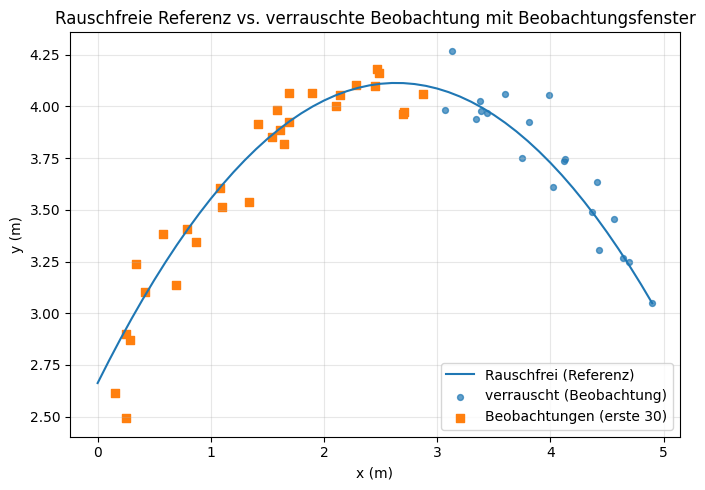

In [6]:
# === Plot: Einzelbeispiel (Clean vs. Noisy) + Beobachtungsfenster ===
# Wähle ein Beispiel (zufällig, aber reproduzierbar über SEED)
example = per_throw.sample(1, random_state=SEED).iloc[0]
wurf_id = int(example["wurf_id"])
label = int(example["label"])

g = df[df["wurf_id"] == wurf_id].sort_values("t").reset_index(drop=True)

n_obs = 30
n_obs = min(n_obs, len(g))

plt.figure(figsize=(7, 5))

# (i) rauschfreie Trajektorie als Kurve
plt.plot(g["x_clean"].values, g["y_clean"].values, label="Rauschfrei (Referenz)")

# (ii) verrauschte Stützstellen
plt.scatter(
    g["x_noisy"].values,
    g["y_noisy"].values,
    s=18,
    alpha=0.7,
    label="verrauscht (Beobachtung)",
)

# Markierung des Beobachtungspräfix (erste n_obs Punkte)
plt.scatter(
    g.loc[: n_obs - 1, "x_noisy"].values,
    g.loc[: n_obs - 1, "y_noisy"].values,
    s=40,
    marker="s",
    label=f"Beobachtungen (erste {n_obs})",
)

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title(f"Rauschfreie Referenz vs. verrauschte Beobachtung mit Beobachtungsfenster")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 4) Modell: Encoder → (θ,v0) + Decoder (x,y) + Klassifikations-Head

In [7]:
class MLP(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, hidden: int = 128, depth: int = 3, dropout: float = 0.0):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers += [nn.Linear(d, hidden), nn.Tanh()]
            if dropout > 0:
                layers += [nn.Dropout(dropout)]
            d = hidden
        layers += [nn.Linear(d, out_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

class AmortizedPINNClassifier(nn.Module):
    """
    Encoder (GRU) ueber beobachtete Sequenz -> Latent z.
    Heads: theta, v0, Klassifikation.
    Decoder: amortisiertes PINN, bekommt KEIN T/t_max, sondern
    - normierte Zeit t_n
    - log_denom = log(t_obs_max - t_min) als Skalierungskontext
    """
    def __init__(
        self,
        enc_hidden: int = 128,
        z_dim: int = 128,
        dec_hidden: int = 128,
        num_classes: int = 3,
        theta_min: float = 0.5,
        theta_max: float = 1.2,
        v0_min: float = 0.0
    ):
        super().__init__()
        self.theta_min = theta_min
        self.theta_max = theta_max
        self.v0_min = v0_min

        # Encoder input: (t_n, x, y)
        self.in_proj = nn.Linear(3, enc_hidden)
        self.gru = nn.GRU(input_size=enc_hidden, hidden_size=enc_hidden, batch_first=True)
        self.to_z = nn.Linear(enc_hidden, z_dim)

        self.theta_head = MLP(z_dim, 1, hidden=128, depth=2)
        self.v0_head    = MLP(z_dim, 1, hidden=128, depth=2)

        # Decoder input: z + (t_n, log_denom)
        self.decoder = MLP(z_dim + 2, 2, hidden=dec_hidden, depth=3)

        self.classifier = MLP(z_dim + 2, num_classes, hidden=128, depth=2, dropout=0.1)

    def encode(self, t_n_obs, xy_obs):
        inp = torch.cat([t_n_obs.unsqueeze(-1), xy_obs], dim=-1)  # (B,n,3)
        h = torch.tanh(self.in_proj(inp))
        _, hT = self.gru(h)  # (1,B,H)
        z = self.to_z(hT.squeeze(0))
        return z

    def predict_params(self, z):
        theta_raw = self.theta_head(z).squeeze(-1)
        v0_raw = self.v0_head(z).squeeze(-1)
        theta = self.theta_min + (self.theta_max - self.theta_min) * torch.sigmoid(theta_raw)
        v0 = self.v0_min + F.softplus(v0_raw)
        return theta, v0

    def decode_traj(self, z, t_n, log_denom):
        B, N = t_n.shape
        logd = log_denom.unsqueeze(1).expand(-1, N)  # [B,N]
        inp = torch.cat([
            z.unsqueeze(1).expand(-1, N, -1),
            t_n.unsqueeze(-1),
            logd.unsqueeze(-1),
        ], dim=-1)
        return self.decoder(inp)

    def forward(self, t_n_obs, xy_obs, t_n_query, log_denom):
        z = self.encode(t_n_obs, xy_obs)
        theta, v0 = self.predict_params(z)
        xy_hat = self.decode_traj(z, t_n_query, log_denom)
        logits = self.classifier(torch.cat([z, theta.unsqueeze(-1), v0.unsqueeze(-1)], dim=-1))
        return {"z": z, "theta": theta, "v0": v0, "xy_hat": xy_hat, "logits": logits}

model = AmortizedPINNClassifier(num_classes=int(df["label"].nunique())).to(device)
sum(p.numel() for p in model.parameters())

266119

## 5) Loss: Daten + Physik + IC + Klassifikation (+ Param-Supervision)

In [8]:
G = 9.81
H_RIM = 3.048  # 10 ft in meters
import math

def normalize_time(t, t_min, denom):
    # t: [B,N] oder [B]
    if t.dim() == 1:
        return (t - t_min) / denom
    return (t - t_min.unsqueeze(1)) / denom.unsqueeze(1)

def denormalize_time(t_n, t_min, denom):
    # t_n: [B,N]
    return t_min.unsqueeze(1) + t_n * denom.unsqueeze(1)

def time_to_height(theta, v0, y0, h=H_RIM, g=G, eps=1e-9):
    """
    Liefert t_hit_rel (>=0) relativ zu t_min, so dass:
      y(t_rel) = y0 + v0*sin(theta)*t_rel - 0.5*g*t_rel^2 = h
    plus valid-Flag (Diskriminante > 0 und t_hit > 0).
    """
    a = 0.5 * g
    b = -v0 * torch.sin(theta)
    c = h - y0

    disc = b*b - 4*a*c
    disc_clamped = torch.clamp(disc, min=0.0)
    sqrt_disc = torch.sqrt(disc_clamped + eps)

    t1 = (-b - sqrt_disc) / (2*a)
    t2 = (-b + sqrt_disc) / (2*a)

    # spaetere Loesung (typisch Abstieg)
    t_hit = torch.maximum(t1, t2)
    valid = (disc > 0) & (t_hit > 0)
    return t_hit, valid

def make_query_times_until_rim_height(
    t_min, t_obs_max, denom, theta, v0, y0,
    dt, h_rim=H_RIM,
    t_end_min_offset=0.0,
    t_end_max_offset=3.0
):
    """
    Erzeugt Query-Zeitpunkte (physikalische Zeit) von t_min bis zur (modellbasierten) Zeit,
    zu der y(t) die Korbhöhe h_rim erreicht (spätere Lösung, typ. Abstieg).
    Wichtig: Es wird kein t_full benötigt -> kein Zukunftswissen über Sequenzende.

    Erwartet B=1 (Tensor-Skalare als Shape [1]).
    """
    # robustes dt
    dt = float(dt) if dt is not None else 0.02
    dt = max(dt, 1e-4)

    t_hit_rel, valid = time_to_height(theta, v0, y0, h=h_rim)
    t_hit_abs = t_min + t_hit_rel

    t_end_raw = torch.where(valid, t_hit_abs, t_obs_max + t_end_max_offset)
    t_end = torch.clamp(
        t_end_raw,
        min=t_obs_max + t_end_min_offset,
        max=t_obs_max + t_end_max_offset
    )

    # grid <= t_end, plus ggf. exakter Endpunkt
    t_min_val = float(t_min.item())
    t_end_val = float(t_end.item())

    N = int(math.floor((t_end_val - t_min_val) / dt)) + 1
    N = max(N, 2)
    t = t_min_val + torch.arange(N, device=t_min.device, dtype=t_min.dtype) * dt

    # keine Überschreitung: ggf. letzten Punkt auf t_end setzen oder t_end anhängen
    if float(t[-1].item()) > t_end_val + 1e-9:
        t[-1] = t_end.squeeze()
    elif float(t[-1].item()) < t_end_val - 1e-9:
        t = torch.cat([t, t_end.squeeze().unsqueeze(0)], dim=0)

    return t.unsqueeze(0)  # [1,N]


def trim_prediction_at_rim_height(t_query_1d, xy_hat_2d, h_rim=H_RIM, eps=1e-9):
    """
    Schneidet die Vorhersage so ab, dass sie maximal bis zur Korbhöhe reicht.
    Falls ein Schnitt zwischen zwei Punkten liegt, wird linear auf y=h_rim interpoliert.

    t_query_1d: [N]
    xy_hat_2d:  [N,2]
    """
    y = xy_hat_2d[:, 1]
    above = y >= (h_rim - eps)

    if not torch.any(above):
        return t_query_1d, xy_hat_2d

    last_above = int(torch.where(above)[0][-1].item())
    if last_above >= (len(y) - 1):
        return t_query_1d[: last_above + 1], xy_hat_2d[: last_above + 1]

    # Interpolation zwischen last_above und next
    y1, y2 = y[last_above], y[last_above + 1]
    dy = (y2 - y1)
    if torch.abs(dy) < 1e-12:
        return t_query_1d[: last_above + 1], xy_hat_2d[: last_above + 1]

    alpha = (h_rim - y1) / dy
    alpha = torch.clamp(alpha, 0.0, 1.0)

    x1, x2 = xy_hat_2d[last_above, 0], xy_hat_2d[last_above + 1, 0]
    t1, t2 = t_query_1d[last_above], t_query_1d[last_above + 1]

    x_cross = x1 + alpha * (x2 - x1)
    t_cross = t1 + alpha * (t2 - t1)

    xy_cross = torch.stack([
        x_cross,
        torch.tensor(h_rim, device=xy_hat_2d.device, dtype=xy_hat_2d.dtype)
    ], dim=0)

    t_new = torch.cat([t_query_1d[: last_above + 1], t_cross.unsqueeze(0)], dim=0)
    xy_new = torch.cat([xy_hat_2d[: last_above + 1], xy_cross.unsqueeze(0)], dim=0)

    return t_new, xy_new



def physics_residuals_time_normed(out, t_n, t_min, denom):
    """
    out["xy_hat"] ist bei t_n ausgewertet (t_n hat requires_grad=True).
    Autograd liefert Ableitungen nach t_n -> per Kettenregel nach phys. Zeit umrechnen.
    """
    xy = out["xy_hat"]
    x = xy[..., 0]
    y = xy[..., 1]
    theta = out["theta"]
    v0 = out["v0"]

    ones = torch.ones_like(x)
    dx_dt_n = torch.autograd.grad(x, t_n, grad_outputs=ones, create_graph=True, retain_graph=True)[0]
    dy_dt_n = torch.autograd.grad(y, t_n, grad_outputs=ones, create_graph=True, retain_graph=True)[0]

    # Kettenregel: t_n = (t - t_min)/denom  => dt_n/dt = 1/denom
    dx_dt = dx_dt_n / denom.unsqueeze(1)
    dy_dt = dy_dt_n / denom.unsqueeze(1)

    # Physik nutzt t_rel = t - t_min (Zeit seit Beginn der Observations)
    t_phys = denormalize_time(t_n, t_min, denom)
    t_rel = t_phys - t_min.unsqueeze(1)

    target_dx = v0.unsqueeze(1) * torch.cos(theta).unsqueeze(1)
    target_dy = v0.unsqueeze(1) * torch.sin(theta).unsqueeze(1) - G * t_rel

    rx = dx_dt - target_dx
    ry = dy_dt - target_dy
    return rx, ry

def compute_losses(
    batch, model,
    n_col=64,
    h_rim=H_RIM,
    t_end_min_offset=0.25,
    t_end_max_offset=3.0,
    w_data=15.0, w_phys=0.5, w_ic=10.0, w_cls=0.01
):
    t_obs   = batch["t_obs"].to(device)      # [B,n_obs]
    xy_obs  = batch["xy_obs"].to(device)     # [B,n_obs,2]
    label   = batch["label"].to(device)

    t_min   = batch["t_min"].to(device)          # [B]
    t_obs_max = batch["t_obs_max"].to(device)    # [B]
    denom   = batch["denom"].to(device).clamp_min(1e-4)  # [B]
    log_denom = torch.log(denom)

    # normalisierte Zeit: Beobachtungen in [0,1], Zukunft bei >1
    t_n_obs = normalize_time(t_obs, t_min, denom)

    # Data + Classification auf Beobachtungen
    out_obs = model(t_n_obs, xy_obs, t_n_obs, log_denom)
    data_loss = F.mse_loss(out_obs["xy_hat"], xy_obs)

    # IC bei t_n=0 (t=t_min): passt den ersten Punkt an (robuster als x(0)=0 Annahme)
    t0_n = torch.zeros((t_obs.shape[0], 1), device=device)
    out0 = model(t_n_obs, xy_obs, t0_n, log_denom)
    ic_loss = F.mse_loss(out0["xy_hat"].squeeze(1), xy_obs[:, 0, :])

    # Dynamisches Collocation-Ende bis Korbhöhe (ballistisch) + Sicherheitsfenster
    y0 = xy_obs[:, 0, 1]  # Starthöhe aus Beobachtung (kein Oracle)
    theta = out_obs["theta"]
    v0 = out_obs["v0"]

    t_hit_rel, valid = time_to_height(theta, v0, y0, h=h_rim)
    t_hit_abs = t_min + t_hit_rel

    t_end_raw = torch.where(valid, t_hit_abs, t_obs_max + t_end_max_offset)
    t_end = torch.clamp(
        t_end_raw,
        min=t_obs_max + t_end_min_offset,
        max=t_obs_max + t_end_max_offset
    ).detach()  # detach gegen "Cheating" ueber t_end

    # Collocation-Zeiten pro Sample: t ~ U(t_min, t_end)
    B = t_obs.shape[0]
    u = torch.rand((B, n_col), device=device)
    t_col = t_min.unsqueeze(1) + u * (t_end.unsqueeze(1) - t_min.unsqueeze(1))  # [B,n_col]
    t_n_col = normalize_time(t_col, t_min, denom)                                # [B,n_col]
    t_n_col.requires_grad_(True)

    out_col = model(t_n_obs, xy_obs, t_n_col, log_denom)
    rx, ry = physics_residuals_time_normed(out_col, t_n_col, t_min, denom)
    phys_loss = rx.pow(2).mean() + ry.pow(2).mean()

    # Classification
    cls_loss = F.cross_entropy(out_obs["logits"], label)

    total = w_data*data_loss + w_ic*ic_loss + w_phys*phys_loss + w_cls*cls_loss

    return total, {
        "total": total.detach().item(),
        "data": data_loss.detach().item(),
        "ic": ic_loss.detach().item(),
        "phys": phys_loss.detach().item(),
        "cls": cls_loss.detach().item(),
    }

def compute_mse_obs_future(pred_xy, gt_xy, n_obs: int):
    """
    pred_xy, gt_xy: Tensor [B, T, 2]
    """
    mse_obs = F.mse_loss(pred_xy[:, :n_obs, :], gt_xy[:, :n_obs, :], reduction="mean")
    mse_future = F.mse_loss(pred_xy[:, n_obs:, :], gt_xy[:, n_obs:, :], reduction="mean")
    return mse_obs.item(), mse_future.item()

## 6) Training (mit Early Stopping)

In [9]:
def run_epoch(loader, model, optimizer=None, **loss_kwargs):
    is_train = optimizer is not None
    model.train(is_train)
    meters = {"total":0, "data":0, "ic":0, "phys":0, "cls":0}
    n_batches = 0

    for batch in loader:
        if is_train:
            optimizer.zero_grad(set_to_none=True)

        total, parts = compute_losses(batch, model, **loss_kwargs)

        if is_train:
            total.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        for k in meters:
            meters[k] += parts[k]
        n_batches += 1

    for k in meters:
        meters[k] /= max(n_batches,1)
    return meters

def train_model(model, train_loader, val_loader, epochs=200, lr=2e-3, patience=25, **loss_kwargs):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best = float("inf")
    best_state = None
    bad = 0
    history = {"train":[], "val":[]}

    for epoch in range(1, epochs+1):
        tr = run_epoch(train_loader, model, optimizer=optimizer, **loss_kwargs)
        va = run_epoch(val_loader, model, optimizer=None, **loss_kwargs)
        history["train"].append(tr)
        history["val"].append(va)

        if va["total"] < best - 1e-5:
            best = va["total"]
            best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:4d} | train {tr['total']:.4f} | val {va['total']:.4f} "
                  f"(data {va['data']:.4f}, phys {va['phys']:.4f}, cls {va['cls']:.4f})")

        if bad >= patience:
            print("Early stopping.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return history

history = train_model(
    model,
    train_loader,
    val_loader,
    epochs=200,
    lr=2e-3,
    patience=25,
    n_col=64,
    w_data=5.0,
    w_phys=1.0,
    w_ic=10.0,
    w_cls=0.01,
)

Epoch    1 | train 408.2201 | val 15.6723 (data 0.6792, phys 7.4158, cls 1.1196)
Epoch   10 | train 12.6287 | val 12.3175 (data 1.0985, phys 5.6312, cls 1.1985)
Epoch   20 | train 8.4797 | val 7.0533 (data 0.1863, phys 5.4998, cls 1.0979)
Epoch   30 | train 7.2182 | val 5.7986 (data 0.2460, phys 4.4889, cls 1.0878)
Epoch   40 | train 2.8003 | val 2.8227 (data 0.1739, phys 1.5329, cls 1.0935)
Epoch   50 | train 1.5859 | val 1.3562 (data 0.1186, phys 0.6551, cls 0.8313)
Epoch   60 | train 0.5116 | val 0.7013 (data 0.0566, phys 0.3669, cls 0.5792)
Epoch   70 | train 0.9417 | val 0.8869 (data 0.0379, phys 0.6575, cls 0.7660)
Epoch   80 | train 0.3062 | val 0.2080 (data 0.0233, phys 0.0414, cls 0.4263)
Epoch   90 | train 0.1871 | val 0.1770 (data 0.0107, phys 0.0854, cls 0.2653)
Epoch  100 | train 0.1335 | val 0.2684 (data 0.0197, phys 0.0826, cls 0.3107)
Early stopping.


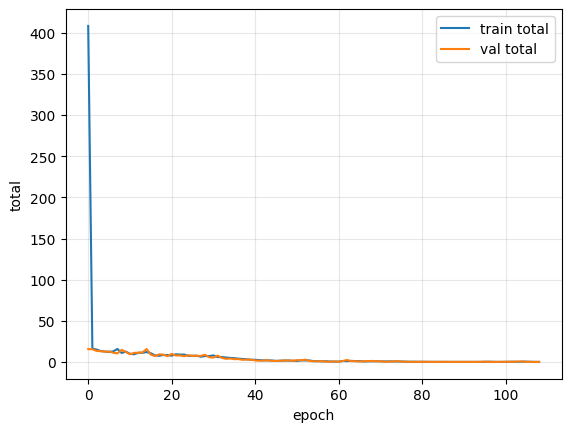

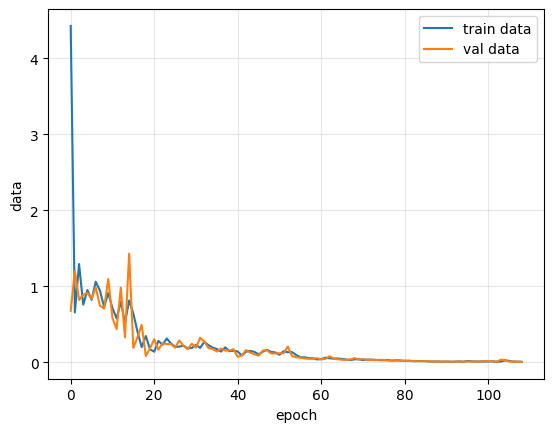

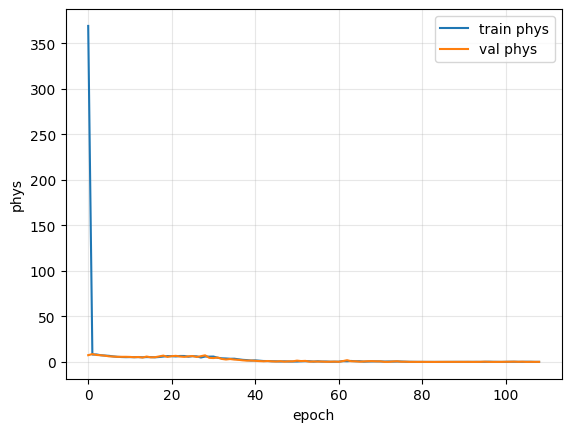

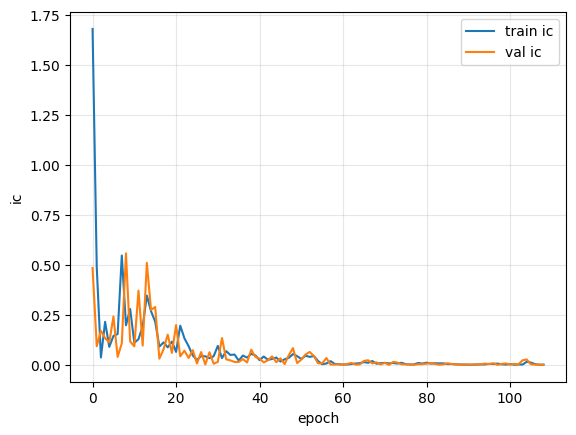

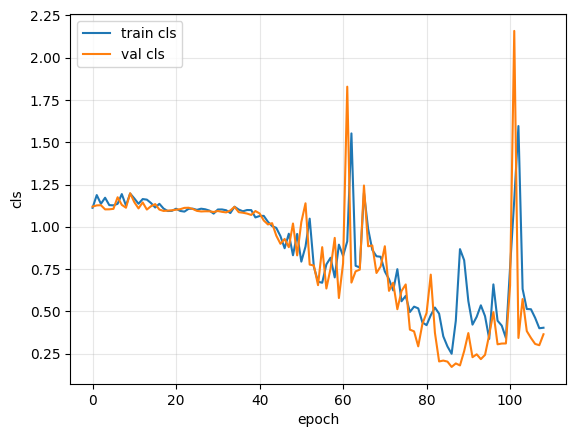

In [10]:
def plot_history(history, key="total"):
    tr = [h[key] for h in history["train"]]
    va = [h[key] for h in history["val"]]
    plt.figure()
    plt.plot(tr, label=f"train {key}")
    plt.plot(va, label=f"val {key}")
    plt.xlabel("epoch"); plt.ylabel(key); plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()

for k in ["total","data","phys","ic","cls"]:
    plot_history(history, k)

## 7) Evaluation auf Testset

Accuracy: 0.9565217391304348

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.88      0.93         8
           1       0.89      1.00      0.94         8
           2       1.00      1.00      1.00         7

    accuracy                           0.96        23
   macro avg       0.96      0.96      0.96        23
weighted avg       0.96      0.96      0.96        23

theta MAE:    0.05935 rad
v0 MAE:       0.39558 m/s
traj MSE full:0.048674
traj MSE obs: 0.015298
traj MSE fut: 0.098738


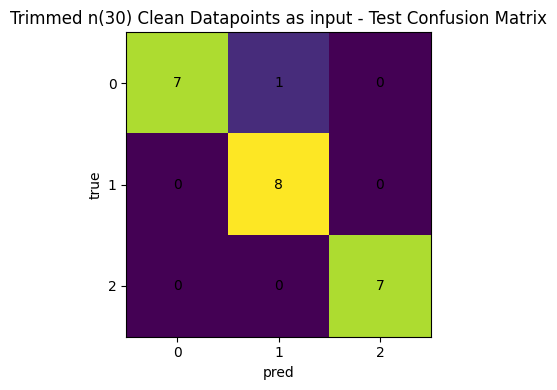

In [11]:
def plot_confusion_matrix(cm, title="Confusion Matrix", ax=None):
    """
    Plottet eine Confusion Matrix wie im Screenshot (imshow + Zahlen),
    mit frei übergebbarem Titel.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    else:
        fig = ax.figure

    im = ax.imshow(cm, interpolation="nearest")  # Standard-Colormap wie im Screenshot

    # Achsenbeschriftungen
    ax.set_title(title)
    ax.set_xlabel("pred")
    ax.set_ylabel("true")

    # Ticks 0..C-1
    C = cm.shape[0]
    ax.set_xticks(np.arange(C))
    ax.set_yticks(np.arange(C))
    ax.set_xticklabels([str(i) for i in range(C)])
    ax.set_yticklabels([str(i) for i in range(C)])

    # Zahlen in die Zellen
    for i in range(C):
        for j in range(C):
            ax.text(j, i, str(int(cm[i, j])), ha="center", va="center", color="black")

    # verhindert abgeschnittene Achsen bei manchen Backends
    ax.set_ylim(C - 0.5, -0.5)

    fig.tight_layout()
    return fig, ax


@torch.no_grad()
def evaluate(loader, model, titel):
    model.eval()
    y_true, y_pred = [], []
    theta_true, theta_pred = [], []
    v0_true, v0_pred = [], []

    mse_obs_list = []
    mse_future_list = []
    mse_full_list = []

    for batch in loader:
        t_obs  = batch["t_obs"].to(device)      # [B,n_obs]
        xy_obs = batch["xy_obs"].to(device)     # [B,n_obs,2]
        t_full = batch["t_full"].to(device)     # [B,M]
        xy_full = batch["xy_full"].to(device)   # [B,M,2]

        t_min = batch["t_min"].to(device)       # [B]
        denom = batch["denom"].to(device).clamp_min(1e-4)  # [B]
        log_denom = torch.log(denom)

        t_n_obs  = normalize_time(t_obs, t_min, denom)     # [B,n_obs]
        t_n_full = normalize_time(t_full, t_min, denom)    # [B,M]

        out = model(t_n_obs, xy_obs, t_n_full, log_denom)

        pred = out["logits"].argmax(dim=1).cpu().numpy()
        y_pred.extend(pred.tolist())
        y_true.extend(batch["label"].numpy().tolist())

        theta_pred.extend(out["theta"].cpu().numpy().tolist())
        v0_pred.extend(out["v0"].cpu().numpy().tolist())
        theta_true.extend(batch["theta"].numpy().tolist())
        v0_true.extend(batch["v0"].numpy().tolist())

        mse_full = F.mse_loss(out["xy_hat"], xy_full, reduction="mean").item()
        mse_full_list.append(mse_full)

        mse_obs, mse_future = compute_mse_obs_future(out["xy_hat"], xy_full, n_obs=n_obs)
        mse_obs_list.append(mse_obs)
        mse_future_list.append(mse_future)

    acc = accuracy_score(y_true, y_pred)
    print("Accuracy:", acc)
    print("\nClassification report:\n", classification_report(y_true, y_pred))
    plot_confusion_matrix(
        confusion_matrix(y_true, y_pred),
        title=titel
    )

    theta_mae = np.mean(np.abs(np.array(theta_pred) - np.array(theta_true)))
    v0_mae = np.mean(np.abs(np.array(v0_pred) - np.array(v0_true)))
    print(f"theta MAE:    {theta_mae:.5f} rad")
    print(f"v0 MAE:       {v0_mae:.5f} m/s")
    print(f"traj MSE full:{np.mean(mse_full_list):.6f}")
    print(f"traj MSE obs: {np.mean(mse_obs_list):.6f}")
    print(f"traj MSE fut: {np.nanmean(mse_future_list):.6f}")


evaluate(test_loader, model, titel="Trimmed n(30) Clean Datapoints as input - Test Confusion Matrix")

## 8) Demo: Rekonstruktion + Klassifikation für einen einzelnen Wurf

Wurf 1 | true label=1 | pred label=1
theta true=0.8891, pred=0.8675
v0    true=6.6624, pred=6.6675


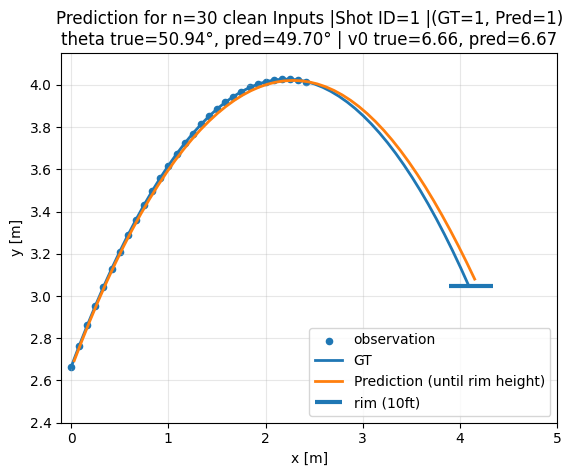

In [12]:
@torch.no_grad()
def demo_reconstruction(model, ds, n_obs=None, idx=0):
    s = ds[idx]
    wurf_id = s["wurf_id"]

    t_obs = s["t_obs"].unsqueeze(0).to(device)
    xy_obs = s["xy_obs"].unsqueeze(0).to(device)

    t_min = s["t_min"].unsqueeze(0).to(device)
    t_obs_max = s["t_obs_max"].unsqueeze(0).to(device)
    denom = s["denom"].unsqueeze(0).to(device).clamp_min(1e-4)
    log_denom = torch.log(denom)

    t_n_obs = normalize_time(t_obs, t_min, denom)

    # Inferenz von (theta, v0) ausschließlich aus Beobachtungen
    out_obs = model(t_n_obs, xy_obs, t_n_obs, log_denom)
    theta_pred = out_obs["theta"]
    v0_pred = out_obs["v0"]

    # Query-Zeiten bis Korbhöhe (kein t_full als Input)
    if t_obs.shape[1] > 1:
        dt = float((t_obs[:, 1:] - t_obs[:, :-1]).mean().item())
    else:
        dt = 0.02

    y0 = xy_obs[:, 0, 1]
    t_query = make_query_times_until_rim_height(
        t_min=t_min, t_obs_max=t_obs_max, denom=denom,
        theta=theta_pred, v0=v0_pred, y0=y0,
        dt=dt, h_rim=H_RIM
    )  # [1,N]

    t_n_query = normalize_time(t_query, t_min, denom)

    out = model(t_n_obs, xy_obs, t_n_query, log_denom)
    xy_hat_t = out["xy_hat"].squeeze(0)  # [N,2]
    t_q_1d = t_query.squeeze(0)

    # Hartes Abschneiden bei Korbhöhe (verhindert unnötige Extrapolation unterhalb der Ebene)
    t_q_trim, xy_hat_trim = trim_prediction_at_rim_height(t_q_1d, xy_hat_t, h_rim=H_RIM)

    xy_hat = xy_hat_trim.detach().cpu().numpy()
    xy_obs_np = s["xy_obs"].numpy()

    # Ground Truth nur für Visualisierung (kein Input)
    xy_full = s["xy_full"].numpy()

    theta_gt = float(s["theta"].item())
    v0_gt = float(s["v0"].item())
    theta_pred_val = float(theta_pred.item())
    v0_pred_val = float(v0_pred.item())

    theta_pred_deg = math.degrees(theta_pred_val)
    theta_gt_deg = math.degrees(theta_gt)

    pred_label = int(out["logits"].argmax(dim=1).item())
    print(f"Wurf {wurf_id} | true label={s['label'].item()} | pred label={pred_label}")
    print(f"theta true={theta_gt:.4f}, pred={theta_pred_val:.4f}")
    print(f"v0    true={v0_gt:.4f}, pred={v0_pred_val:.4f}")

    plt.figure()
    plt.scatter(xy_obs_np[:, 0], xy_obs_np[:, 1], s=20, label="observation")
    plt.plot(xy_full[:, 0], xy_full[:, 1], linewidth=2, label="GT")
    plt.plot(xy_hat[:, 0], xy_hat[:, 1], linewidth=2, label="Prediction (until rim height)")

    plt.hlines(y=3.048, xmin=4.115 - 0.2286, xmax=4.115 + 0.2286, linewidth=3, label="rim (10ft)")

    plt.title(
        f"Prediction for n={n_obs} clean Inputs |"
        f"Shot ID={wurf_id} |"
        f"(GT={int(s['label'].item())}, Pred={pred_label})\n"
        f"theta true={theta_gt_deg:.2f}°, pred={theta_pred_deg:.2f}° | v0 true={v0_gt:.2f}, pred={v0_pred_val:.2f}"
    )
    plt.xlabel("x [m]"); plt.ylabel("y [m]"); plt.legend(); plt.grid(True, alpha=0.3)
    plt.xlim(-0.1, 5)
    plt.ylim(2.4, 4.15)
    plt.show()

import math
import numpy as np
import matplotlib.pyplot as plt
import torch


@torch.no_grad()
def demo_reconstruction_noisy_vs_clean(model, ds_noisy, ds_clean, n_obs=None, idx=0):
    """
    ds_noisy: Dataset mit use_noisy=True (Inputs sind noisy)
    ds_clean: Dataset mit use_noisy=False (GT-Trajektorie ist clean)
    """
    # --- noisy sample ---
    sN = ds_noisy[idx]
    wurf_id = sN["wurf_id"]

    # --- find matching clean sample by wurf_id ---
    if not hasattr(demo_reconstruction_noisy_vs_clean, "_clean_index") or getattr(
        demo_reconstruction_noisy_vs_clean, "_clean_index_ds_id", None
    ) != id(ds_clean):
        clean_index = {}
        for j in range(len(ds_clean)):
            wj = ds_clean[j]["wurf_id"]
            clean_index[wj] = j
        demo_reconstruction_noisy_vs_clean._clean_index = clean_index
        demo_reconstruction_noisy_vs_clean._clean_index_ds_id = id(ds_clean)

    clean_index = demo_reconstruction_noisy_vs_clean._clean_index
    if wurf_id not in clean_index:
        raise KeyError(f"wurf_id={wurf_id} nicht im ds_clean gefunden. Prüfe Split/IDs.")

    sC = ds_clean[clean_index[wurf_id]]

    # --- model forward: nur noisy Beobachtungen, Query-Zeiten dynamisch bis Korbhöhe ---
    t_obs = sN["t_obs"].unsqueeze(0).to(device)
    xy_obs = sN["xy_obs"].unsqueeze(0).to(device)

    t_min = sN["t_min"].unsqueeze(0).to(device)
    t_obs_max = sN["t_obs_max"].unsqueeze(0).to(device)
    denom = sN["denom"].unsqueeze(0).to(device).clamp_min(1e-4)
    log_denom = torch.log(denom)

    t_n_obs = normalize_time(t_obs, t_min, denom)

    # Parameter aus Beobachtungen (kein t_full)
    out_obs = model(t_n_obs, xy_obs, t_n_obs, log_denom)
    theta_pred = out_obs["theta"]
    v0_pred = out_obs["v0"]

    if t_obs.shape[1] > 1:
        dt = float((t_obs[:, 1:] - t_obs[:, :-1]).mean().item())
    else:
        dt = 0.02

    y0 = xy_obs[:, 0, 1]
    t_query = make_query_times_until_rim_height(
        t_min=t_min, t_obs_max=t_obs_max, denom=denom,
        theta=theta_pred, v0=v0_pred, y0=y0,
        dt=dt, h_rim=H_RIM
    )  # [1,N]
    t_n_query = normalize_time(t_query, t_min, denom)

    out = model(t_n_obs, xy_obs, t_n_query, log_denom)
    xy_hat_t = out["xy_hat"].squeeze(0)  # [N,2]
    t_q_1d = t_query.squeeze(0)

    # Abschneiden bei Korbhöhe
    t_q_trim, xy_hat_trim = trim_prediction_at_rim_height(t_q_1d, xy_hat_t, h_rim=H_RIM)
    xy_hat = xy_hat_trim.detach().cpu().numpy()

    # --- arrays for plotting ---
    xy_obs_np = sN["xy_obs"].numpy()           # noisy obs
    xy_gt_clean = sC["xy_full"].numpy()        # clean GT full (nur Plot)

    theta_gt = float(sC["theta"].item())
    v0_gt = float(sC["v0"].item())
    theta_pred_val = float(theta_pred.item())
    v0_pred_val = float(v0_pred.item())

    theta_pred_deg = math.degrees(theta_pred_val)
    theta_gt_deg = math.degrees(theta_gt)

    pred_label = int(out["logits"].argmax(dim=1).item())

    plt.figure()
    plt.scatter(xy_obs_np[:, 0], xy_obs_np[:, 1], s=20, label="noisy observation")
    plt.plot(xy_gt_clean[:, 0], xy_gt_clean[:, 1], linewidth=2, label="actual GT (clean)")
    plt.plot(xy_hat[:, 0], xy_hat[:, 1], linewidth=2, label="Prediction (until rim height)")

    plt.hlines(y=3.048, xmin=4.115 - 0.2286, xmax=4.115 + 0.2286, linewidth=3, label="rim (10ft)")

    plt.title(
        f"Prediction for n={n_obs} noisy Inputs |"
        f"Shot ID={wurf_id} |"
        f"(GT={int(sC['label'].item())}, Pred={pred_label})\n"
        f"theta true={theta_gt_deg:.2f}°, pred={theta_pred_deg:.2f}° | v0 true={v0_gt:.2f}, pred={v0_pred_val:.2f}"
    )
    plt.xlabel("x [m]"); plt.ylabel("y [m]"); plt.legend(); plt.grid(True, alpha=0.3)
    plt.xlim(-0.1, 5)
    plt.ylim(2.4, 4.15)
    plt.show()


demo_reconstruction(model,test_ds, n_obs=30, idx=0)

## 9) Nächster Schritt: Training mit verrauschten Koordinaten

Epoch    1 | train 400.6184 | val 14.3879 (data 0.6935, phys 7.6064, cls 1.0989)
Epoch   10 | train 12.0024 | val 8.5568 (data 0.3472, phys 5.5434, cls 1.1121)
Epoch   20 | train 9.2652 | val 8.7296 (data 0.1071, phys 6.6284, cls 1.1237)
Epoch   30 | train 5.7698 | val 5.3709 (data 0.1682, phys 3.2806, cls 1.0976)
Epoch   40 | train 2.5180 | val 1.9220 (data 0.1056, phys 1.1250, cls 1.0183)
Epoch   50 | train 2.1088 | val 1.9233 (data 0.1515, phys 0.5917, cls 0.8335)
Epoch   60 | train 0.6198 | val 1.3545 (data 0.0721, phys 0.2887, cls 0.4563)
Epoch   70 | train 1.0539 | val 0.7554 (data 0.0380, phys 0.2267, cls 1.0078)
Epoch   80 | train 0.7248 | val 0.6433 (data 0.0305, phys 0.2642, cls 0.7901)
Epoch   90 | train 0.6012 | val 0.3536 (data 0.0221, phys 0.0785, cls 0.3025)
Epoch  100 | train 0.6277 | val 0.7008 (data 0.0259, phys 0.2956, cls 0.5156)
Epoch  110 | train 0.3948 | val 0.7942 (data 0.0399, phys 0.2574, cls 0.2220)
Epoch  120 | train 0.3679 | val 0.5550 (data 0.0360, phys 0.

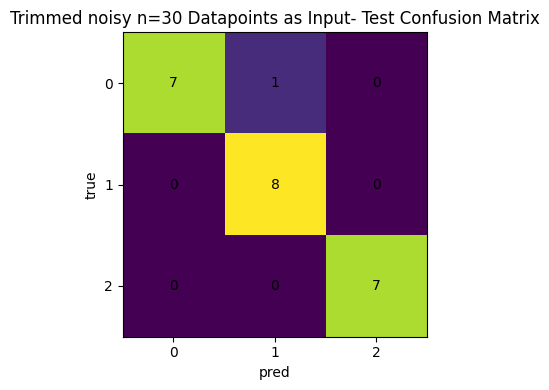

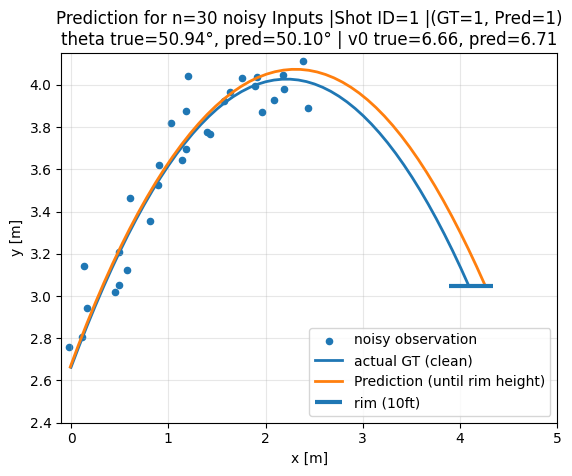

In [13]:
train_ds_noisy = FreeThrowDataset(df, train_ids, n_obs=n_obs, use_noisy=True)
val_ds_noisy   = FreeThrowDataset(df, val_ids,   n_obs=n_obs, use_noisy=True)
test_ds_noisy  = FreeThrowDataset(df, test_ids,  n_obs=n_obs, use_noisy=True)
test_ds_clean  = FreeThrowDataset(df, test_ids,  n_obs=n_obs, use_noisy=False)

train_loader_noisy = DataLoader(train_ds_noisy, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader_noisy   = DataLoader(val_ds_noisy,   batch_size=64, shuffle=False, collate_fn=collate_fn)
test_loader_noisy  = DataLoader(test_ds_noisy,  batch_size=64, shuffle=False, collate_fn=collate_fn)

model = AmortizedPINNClassifier(num_classes=int(df["label"].nunique())).to(device)

history_noisy = train_model(
    model,
    train_loader_noisy,
    val_loader_noisy,
    epochs=200,
    lr=2e-3,
    patience=25,
    n_col=64,
    w_data=5.0,
    w_phys=1.0,
    w_ic=10.0,
    w_cls=0.1,
)

evaluate(
    test_loader_noisy,
    model,
    titel="Trimmed noisy n=30 Datapoints as Input- Test Confusion Matrix",
)

demo_reconstruction_noisy_vs_clean(model,test_ds_noisy, test_ds_clean, n_obs=30, idx=0)

Epoch    1 | train 492.2709 | val 34.1078 (data 1.9099, phys 19.7782, cls 1.1520)
Epoch   10 | train 21.3857 | val 20.1397 (data 1.0008, phys 12.1249, cls 1.1298)
Epoch   20 | train 14.2494 | val 14.1126 (data 0.2834, phys 11.0750, cls 1.1031)
Epoch   30 | train 11.2769 | val 11.2296 (data 0.1986, phys 9.0634, cls 1.1040)
Epoch   40 | train 8.2456 | val 7.6140 (data 0.3763, phys 4.6660, cls 1.0954)
Epoch   50 | train 4.4429 | val 3.9345 (data 0.1636, phys 2.3142, cls 1.0757)
Epoch   60 | train 3.5015 | val 3.4002 (data 0.1745, phys 1.8797, cls 0.6444)
Epoch   70 | train 3.3503 | val 3.5007 (data 0.1936, phys 1.6711, cls 0.7122)
Epoch   80 | train 3.3133 | val 3.2627 (data 0.2465, phys 1.4875, cls 0.3779)
Epoch   90 | train 6.5495 | val 3.6532 (data 0.1434, phys 1.5202, cls 0.5561)
Epoch  100 | train 3.6734 | val 3.5442 (data 0.1865, phys 1.3294, cls 0.6566)
Epoch  110 | train 3.0540 | val 2.4316 (data 0.1469, phys 1.3298, cls 0.5064)
Epoch  120 | train 1.7482 | val 0.8057 (data 0.0601,

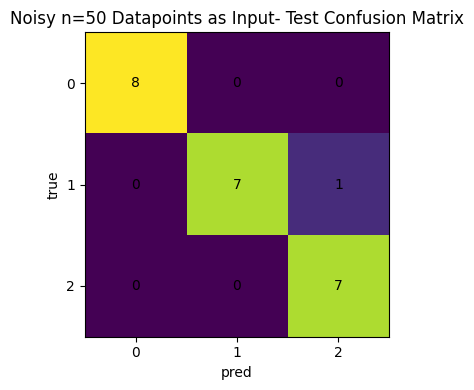

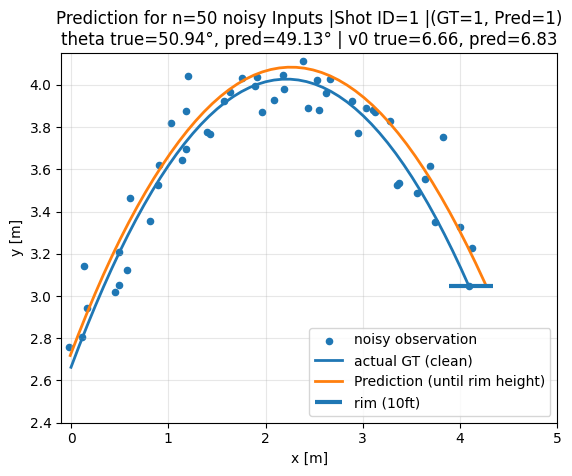

In [14]:
train_ds_noisy = FreeThrowDataset(df, train_ids, n_obs=50, use_noisy=True)
val_ds_noisy = FreeThrowDataset(df, val_ids, n_obs=50, use_noisy=True)
test_ds_noisy = FreeThrowDataset(df, test_ids, n_obs=50, use_noisy=True)
test_ds_clean = FreeThrowDataset(df, test_ids, n_obs=50, use_noisy=False)

train_loader_noisy = DataLoader(
    train_ds_noisy, batch_size=32, shuffle=True, collate_fn=collate_fn
)
val_loader_noisy = DataLoader(
    val_ds_noisy, batch_size=64, shuffle=False, collate_fn=collate_fn
)
test_loader_noisy = DataLoader(
    test_ds_noisy, batch_size=64, shuffle=False, collate_fn=collate_fn
)

model_noisy_50 = AmortizedPINNClassifier(num_classes=int(df["label"].nunique())).to(
    device
)

history_noisy = train_model(
    model_noisy_50,
    train_loader_noisy,
    val_loader_noisy,
    epochs=200,
    lr=2e-3,
    patience=25,
    n_col=64,
    w_data=5.0,
    w_phys=1.0,
    w_ic=10.0,
    w_cls=0.01,
)

evaluate(
    test_loader_noisy,
    model_noisy_50,
    titel="Noisy n=50 Datapoints as Input- Test Confusion Matrix",
)

demo_reconstruction_noisy_vs_clean(
    model_noisy_50, test_ds_noisy, test_ds_clean, n_obs=50, idx=0
)

Epoch    1 | train 341.2850 | val 10.3999 (data 0.3092, phys 5.1813, cls 1.1685)
Epoch   10 | train 9.5410 | val 5.3151 (data 0.2262, phys 3.2623, cls 1.1170)
Epoch   20 | train 1.9373 | val 1.5748 (data 0.0923, phys 0.8508, cls 1.1063)
Epoch   30 | train 2.1388 | val 2.2904 (data 0.0852, phys 1.2763, cls 1.0975)
Epoch   40 | train 1.5482 | val 0.9740 (data 0.0619, phys 0.4977, cls 1.0745)
Epoch   50 | train 1.8558 | val 1.6333 (data 0.0871, phys 0.8206, cls 1.0093)
Epoch   60 | train 1.1075 | val 1.1287 (data 0.0556, phys 0.6412, cls 0.8906)
Epoch   70 | train 0.5136 | val 0.4371 (data 0.0304, phys 0.1135, cls 0.7728)
Epoch   80 | train 0.4300 | val 0.7297 (data 0.0265, phys 0.4470, cls 0.8339)
Epoch   90 | train 0.3468 | val 0.6740 (data 0.0316, phys 0.2558, cls 0.5061)
Epoch  100 | train 0.4749 | val 0.5245 (data 0.0251, phys 0.1594, cls 0.8645)
Epoch  110 | train 0.7938 | val 0.9525 (data 0.0312, phys 0.3734, cls 0.4282)
Epoch  120 | train 0.4309 | val 0.2455 (data 0.0171, phys 0.0

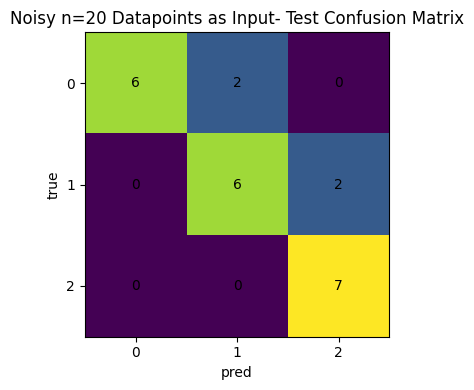

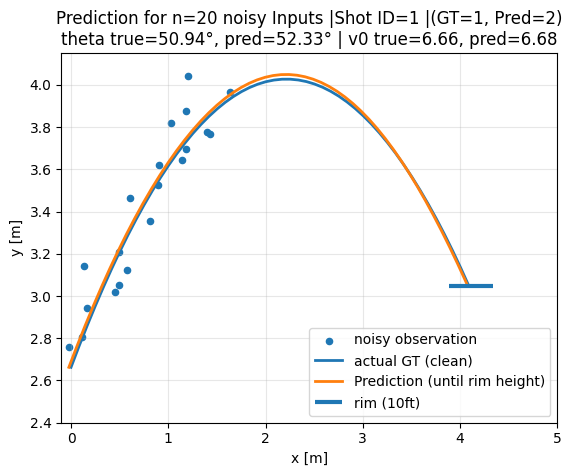

In [15]:
train_ds_noisy = FreeThrowDataset(df, train_ids, n_obs=20, use_noisy=True)
val_ds_noisy = FreeThrowDataset(df, val_ids, n_obs=20, use_noisy=True)
test_ds_noisy = FreeThrowDataset(df, test_ids, n_obs=20, use_noisy=True)
test_ds_clean = FreeThrowDataset(df, test_ids, n_obs=20, use_noisy=False)

train_loader_noisy = DataLoader(
    train_ds_noisy, batch_size=32, shuffle=True, collate_fn=collate_fn
)
val_loader_noisy = DataLoader(
    val_ds_noisy, batch_size=64, shuffle=False, collate_fn=collate_fn
)
test_loader_noisy = DataLoader(
    test_ds_noisy, batch_size=64, shuffle=False, collate_fn=collate_fn
)

model_noisy_20 = AmortizedPINNClassifier(num_classes=int(df["label"].nunique())).to(device)

history_noisy = train_model(
    model_noisy_20,
    train_loader_noisy,
    val_loader_noisy,
    epochs=200,
    lr=2e-3,
    patience=25,
    n_col=64,
    w_data=5.0,
    w_phys=1.0,
    w_ic=10.0,
    w_cls=0.01,
)

evaluate(test_loader_noisy, model_noisy_20, titel ="Noisy n=20 Datapoints as Input- Test Confusion Matrix" )

demo_reconstruction_noisy_vs_clean(model_noisy_20,test_ds_noisy, test_ds_clean, n_obs=20, idx=0)

Epoch    1 | train 354.7286 | val 9.5128 (data 0.3406, phys 6.0689, cls 1.1233)
Epoch   10 | train 10.7818 | val 8.4025 (data 0.2278, phys 3.4372, cls 1.1108)
Epoch   20 | train 2.5743 | val 1.6871 (data 0.1668, phys 0.7947, cls 1.1020)
Epoch   30 | train 1.5692 | val 2.3511 (data 0.0619, phys 1.9143, cls 1.1097)
Epoch   40 | train 2.9709 | val 2.2026 (data 0.0877, phys 1.4434, cls 1.0908)
Early stopping.
Accuracy: 0.34782608695652173

Classification report:
               precision    recall  f1-score   support

           0       0.35      1.00      0.52         8
           1       0.00      0.00      0.00         8
           2       0.00      0.00      0.00         7

    accuracy                           0.35        23
   macro avg       0.12      0.33      0.17        23
weighted avg       0.12      0.35      0.18        23

theta MAE:    0.34287 rad
v0 MAE:       1.97210 m/s
traj MSE full:0.963345
traj MSE obs: 0.331826
traj MSE fut: 1.910622
Wurf 1 | true label=1 | pred label

c:\Users\luca1\Documents\Projekte\BA-Thesis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\luca1\Documents\Projekte\BA-Thesis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\luca1\Documents\Projekte\BA-Thesis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

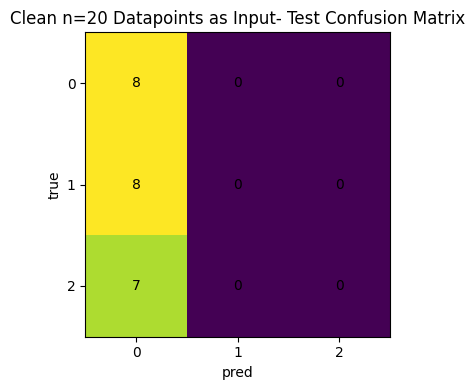

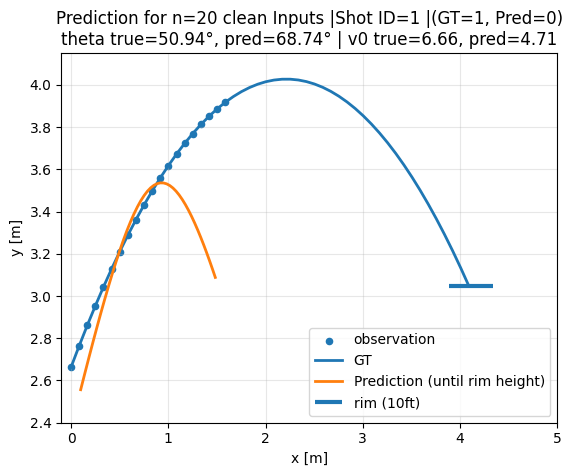

In [16]:
train_ds_clean20 = FreeThrowDataset(df, train_ids, n_obs=20, use_noisy=False)
val_ds_clean20 = FreeThrowDataset(df, val_ids, n_obs=20, use_noisy=False)
test_ds_clean20 = FreeThrowDataset(df, test_ids, n_obs=20, use_noisy=False)

train_loader20 = DataLoader(
    train_ds_clean20, batch_size=32, shuffle=True, collate_fn=collate_fn
)
val_loader20 = DataLoader(
    val_ds_clean20, batch_size=64, shuffle=False, collate_fn=collate_fn
)
test_loader20 = DataLoader(
    test_ds_clean20, batch_size=64, shuffle=False, collate_fn=collate_fn
)

model_clean_20 = AmortizedPINNClassifier(num_classes=int(df["label"].nunique())).to(device)

history_20 = train_model(
    model_clean_20,
    train_loader20,
    val_loader20,
    epochs=200,
    lr=2e-3,
    patience=25,
    n_col=64,
    w_data=5.0,
    w_phys=1.0,
    w_ic=10.0,
    w_cls=0.01,
)

evaluate(test_loader20, model_clean_20, titel="Clean n=20 Datapoints as Input- Test Confusion Matrix")

demo_reconstruction(
    model_clean_20, test_ds_clean20, n_obs=20, idx=0
)

Epoch    1 | train 312.9824 | val 8.2493 (data 0.0852, phys 5.8416, cls 1.1081)
Epoch   10 | train 4.0331 | val 3.2122 (data 0.0611, phys 2.5594, cls 1.1018)
Epoch   20 | train 1.2753 | val 1.2810 (data 0.0776, phys 0.5639, cls 1.0972)
Epoch   30 | train 1.5123 | val 1.2089 (data 0.0330, phys 0.7374, cls 1.1023)
Epoch   40 | train 1.2946 | val 0.9192 (data 0.0384, phys 0.4358, cls 1.1102)
Epoch   50 | train 1.0362 | val 0.8622 (data 0.0302, phys 0.4482, cls 1.0988)
Epoch   60 | train 1.2850 | val 0.5957 (data 0.0261, phys 0.3053, cls 1.0343)
Epoch   70 | train 0.6813 | val 1.1263 (data 0.0413, phys 0.7530, cls 1.0780)
Epoch   80 | train 0.8811 | val 0.7371 (data 0.0489, phys 0.2167, cls 1.0446)
Epoch   90 | train 0.4772 | val 0.3810 (data 0.0259, phys 0.0955, cls 0.9510)
Epoch  100 | train 0.6137 | val 0.5178 (data 0.0322, phys 0.1576, cls 0.9819)
Epoch  110 | train 0.6901 | val 0.3891 (data 0.0233, phys 0.1491, cls 0.9140)
Epoch  120 | train 0.4286 | val 0.3405 (data 0.0227, phys 0.10

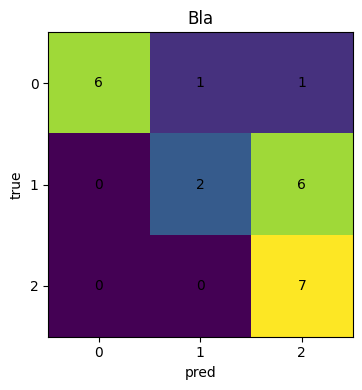

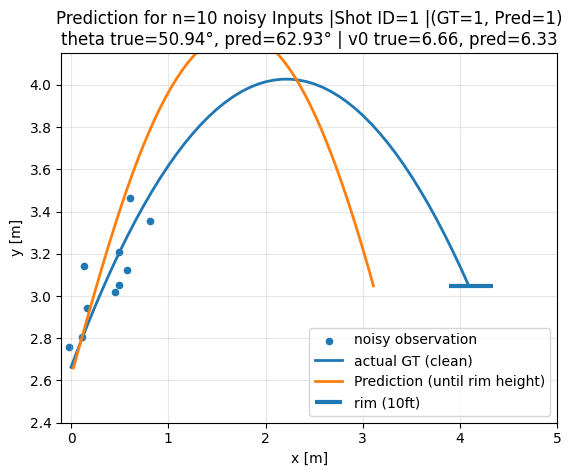

In [17]:
train_ds_noisy = FreeThrowDataset(df, train_ids, n_obs=10, use_noisy=True)
val_ds_noisy = FreeThrowDataset(df, val_ids, n_obs=10, use_noisy=True)
test_ds_noisy = FreeThrowDataset(df, test_ids, n_obs=10, use_noisy=True)
test_ds_clean = FreeThrowDataset(df, test_ids, n_obs=10, use_noisy=False)

train_loader_noisy = DataLoader(
    train_ds_noisy, batch_size=32, shuffle=True, collate_fn=collate_fn
)
val_loader_noisy = DataLoader(
    val_ds_noisy, batch_size=64, shuffle=False, collate_fn=collate_fn
)
test_loader_noisy = DataLoader(
    test_ds_noisy, batch_size=64, shuffle=False, collate_fn=collate_fn
)

model_noisy_10 = AmortizedPINNClassifier(num_classes=int(df["label"].nunique())).to(device)

history_noisy = train_model(
    model_noisy_10,
    train_loader_noisy,
    val_loader_noisy,
    epochs=200,
    lr=2e-3,
    patience=25,
    n_col=64,
    w_data=5.0,
    w_phys=1.0,
    w_ic=10.0,
    w_cls=0.01,
)

evaluate(test_loader_noisy, model_noisy_10, titel = "Bla")

demo_reconstruction_noisy_vs_clean(
    model_noisy_10, test_ds_noisy, test_ds_clean, n_obs=10, idx=0
)

Epoch    1 | train 309.3632 | val 9.3583 (data 0.1207, phys 5.2834, cls 1.1413)
Epoch   10 | train 149.0261 | val 3.0619 (data 0.0898, phys 2.1325, cls 1.1363)
Epoch   20 | train 2.2917 | val 1.5788 (data 0.1061, phys 1.0356, cls 1.0989)
Epoch   30 | train 0.8469 | val 0.9655 (data 0.0888, phys 0.3745, cls 1.1171)
Epoch   40 | train 0.9453 | val 0.9966 (data 0.0591, phys 0.4354, cls 1.0951)
Epoch   50 | train 0.5670 | val 0.4124 (data 0.0213, phys 0.2857, cls 0.9815)
Epoch   60 | train 0.3197 | val 0.3018 (data 0.0155, phys 0.1466, cls 0.9908)
Epoch   70 | train 0.5027 | val 0.5382 (data 0.0188, phys 0.3475, cls 0.9978)
Epoch   80 | train 0.2422 | val 0.3348 (data 0.0150, phys 0.2286, cls 0.9869)
Epoch   90 | train 0.2426 | val 0.2307 (data 0.0161, phys 0.1209, cls 0.9885)
Epoch  100 | train 0.2243 | val 0.1296 (data 0.0115, phys 0.0434, cls 1.0010)
Epoch  110 | train 0.1570 | val 0.1656 (data 0.0078, phys 0.1059, cls 0.9294)
Epoch  120 | train 0.1850 | val 0.3766 (data 0.0155, phys 0.

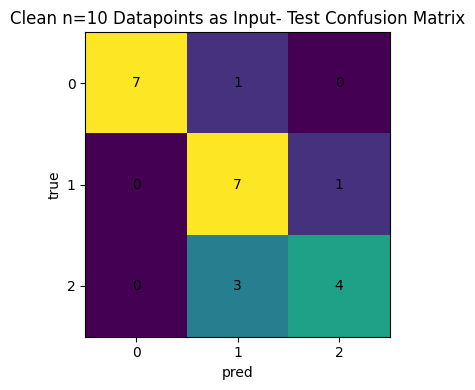

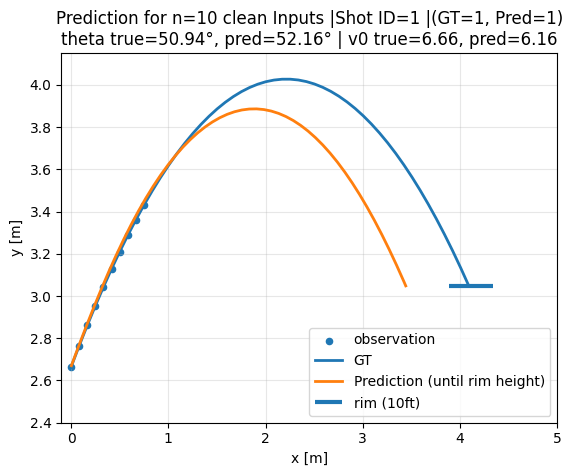

In [18]:
train_ds_clean_10 = FreeThrowDataset(df, train_ids, n_obs=10, use_noisy=False)
val_ds_clean_10 = FreeThrowDataset(df, val_ids, n_obs=10, use_noisy=False)
test_ds_clean_10 = FreeThrowDataset(df, test_ids, n_obs=10, use_noisy=False)

train_loader10 = DataLoader(train_ds_clean_10, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader10 = DataLoader(val_ds_clean_10, batch_size=64, shuffle=False, collate_fn=collate_fn)
test_loader10 = DataLoader(test_ds_clean_10, batch_size=64, shuffle=False, collate_fn=collate_fn)
model_clean_10 = AmortizedPINNClassifier(num_classes=int(df["label"].nunique())).to(device)

model_clean_10 = AmortizedPINNClassifier(num_classes=int(df["label"].nunique())).to(device)

history_10 = train_model(
    model_clean_10,
    train_loader10,
    val_loader10,
    epochs=200,
    lr=2e-3,
    patience=25,
    n_col=64,
    w_data=5.0,
    w_phys=1.0,
    w_ic=10.0,
    w_cls=0.01,
)

evaluate(test_loader10, model_clean_10, titel="Clean n=10 Datapoints as Input- Test Confusion Matrix")

demo_reconstruction(model_clean_10, test_ds_clean_10, n_obs=10, idx=0)